# 1. Attiva l'ambiente (se non lo è già)
source SentimentAnalysis/venv_m2/bin/activate

# 2. Registra il kernel
python -m ipykernel install --user --name=venv_m2 --display-name "Python (Sentiment TripAdvisor)"

In [7]:
import sys
import subprocess

# Disinstalla forzatamente numpy
subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "numpy"])

# Installa la versione compatibile con FastText (minore della 2.0)
subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy<2.0"])

print("✅ DONE! ORA CLICCA SU 'RESTART KERNEL' IN ALTO!")

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Obtaining dependency information for numpy<2.0 from https://files.pythonhosted.org/packages/75/5b/ca6c8bd14007e5ca171c7c03102d17b4f4e0ceb53957e8c44343a9546dcc/numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata
  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
✅ DONE! ORA CLICCA SU 'RESTART KERNEL' IN ALTO!



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
#RUNNARE SOLO LA PRIMA VOLTA POI NON PIU
import nltk
import ssl

# --- FIX PER IL PROBLEMA SSL SU MAC ---
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# --- SCARICAMENTO MANUALE DEI DATI PER TEXTBLOB ---
print("Inizio download...")
nltk.download('brown')
nltk.download('punkt')
nltk.download('punkt_tab')  # Spesso richiesto dalle nuove versioni
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('conll2000')
nltk.download('movie_reviews')
print("Download completato!")

Inizio download...


[nltk_data] Downloading package brown to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to
[nltk_data]     /Users/lorenzogiannetti/nltk_data...
[nltk_data]   U

Download completato!


--- CONTEGGI ORIGINALI ---
sentiment
positive    18799
neutral       911
negative      348
Name: count, dtype: int64

Bilanciamento su: 348 recensioni per classe

--- NUOVO DATASET BILANCIATO (3 CLASSI) ---
sentiment
neutral     348
positive    348
negative    348
Name: count, dtype: int64
Dataset bilanciato salvato come 'LLM_DF_Balanced.csv'


/var/folders/s3/5xdhgys539jg6hfd91tbj95w0000gn/T/ipykernel_82329/3592935340.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tb_category', data=df, palette='pastel', order=['Neutral', 'Positive', 'Negative'])


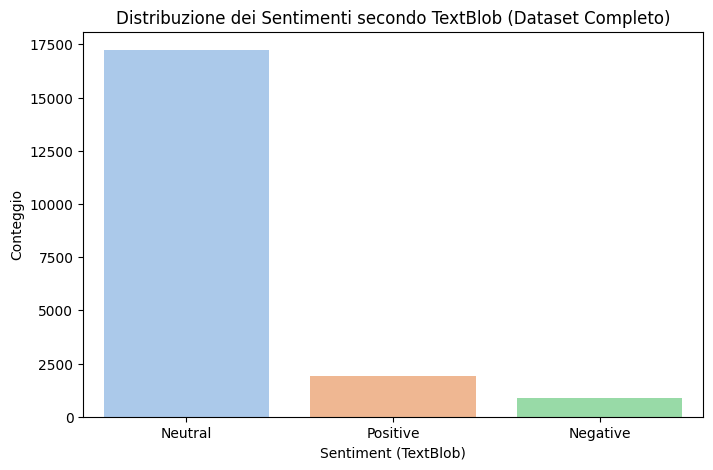

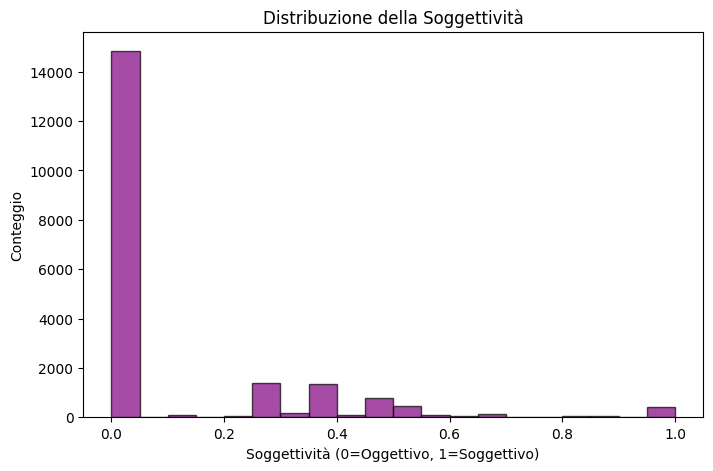

In [ ]:
# Sentiment Analysis (TextBlob)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob

# 1. CARICAMENTO E PULIZIA
df = pd.read_csv('LLM_DF.csv')

# Mappatura: Stelle -> Sentiment
def map_sentiment(star):
    if star >= 4:
        return 'positive'
    elif star <= 2:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['stars'].apply(map_sentiment)

# --- BILANCIAMENTO A 3 CLASSI (Positive, Negative, Neutral) ---
print("--- CONTEGGI ORIGINALI ---")
print(df['sentiment'].value_counts())

# Separiamo le tre classi
df_pos = df[df['sentiment'] == 'positive']
df_neg = df[df['sentiment'] == 'negative']
df_neu = df[df['sentiment'] == 'neutral']

# Troviamo la classe più piccola (probabilmente 'negative')
min_count = min(len(df_pos), len(df_neg), len(df_neu))
print(f"\nBilanciamento su: {min_count} recensioni per classe")

# Campioniamo tutte le classi a questo numero
# (Usiamo random_state=42 per avere sempre lo stesso risultato)
df_pos_bal = df_pos.sample(n=min_count, random_state=42)
df_neu_bal = df_neu.sample(n=min_count, random_state=42)
# Se df_neg è la classe minima, questo prende semplicemente tutte le negative
df_neg_bal = df_neg.sample(n=min_count, random_state=42) 

# Uniamo tutto (Questo è il dataset che useremo per il Machine Learning)
df_balanced = pd.concat([df_pos_bal, df_neg_bal, df_neu_bal])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True) # Mischiamo le righe

print("\n--- NUOVO DATASET BILANCIATO (3 CLASSI) ---")
print(df_balanced['sentiment'].value_counts())

# Salviamo il dataset bilanciato per lo step successivo (FastText)
df_balanced.to_csv('LLM_DF_Balanced.csv', index=False)
print("Dataset bilanciato salvato come 'LLM_DF_Balanced.csv'")

# --- ANALISI TEXTBLOB (SUL DATASET ORIGINALE) ---
# Nota: Solitamente l'analisi descrittiva (come TextBlob) si fa sui dati originali
# per mostrare la realtà "vera", mentre il dataset bilanciato si usa solo per il training del modello.

def get_textblob_sentiment(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['tb_polarity', 'tb_subjectivity']] = df['comment'].apply(
    lambda x: pd.Series(get_textblob_sentiment(x))
)

def categorize_polarity(score):
    if score > 0.1: return 'Positive'
    elif score < -0.1: return 'Negative'
    else: return 'Neutral'

df['tb_category'] = df['tb_polarity'].apply(categorize_polarity)

# GRAFICO 1: Distribuzione Sentiment TextBlob
plt.figure(figsize=(8, 5))
sns.countplot(x='tb_category', data=df, palette='pastel', order=['Neutral', 'Positive', 'Negative'])
plt.title('Distribuzione dei Sentimenti secondo TextBlob (Dataset Completo)')
plt.xlabel('Sentiment (TextBlob)')
plt.ylabel('Conteggio')
plt.show()

# GRAFICO 2: Distribuzione Soggettività
plt.figure(figsize=(8, 5))
plt.hist(df['tb_subjectivity'], bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribuzione della Soggettività')
plt.xlabel('Soggettività (0=Oggettivo, 1=Soggettivo)')
plt.ylabel('Conteggio')
plt.show()

/var/folders/s3/5xdhgys539jg6hfd91tbj95w0000gn/T/ipykernel_82329/348131460.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, order=['positive', 'neutral', 'negative'], palette='viridis')


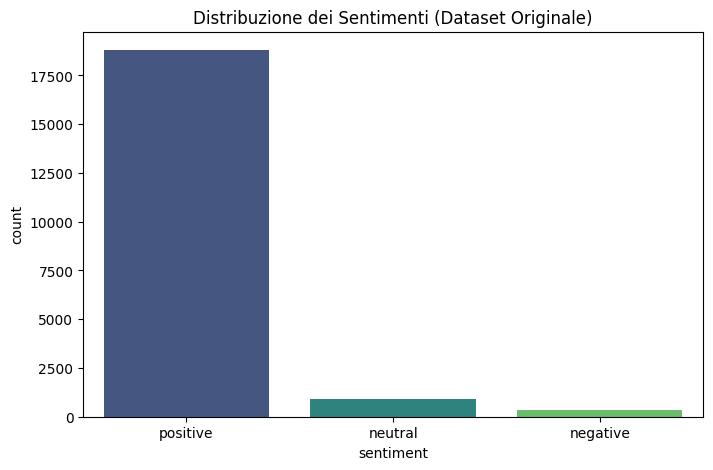

Generazione WordCloud PULITE in corso...


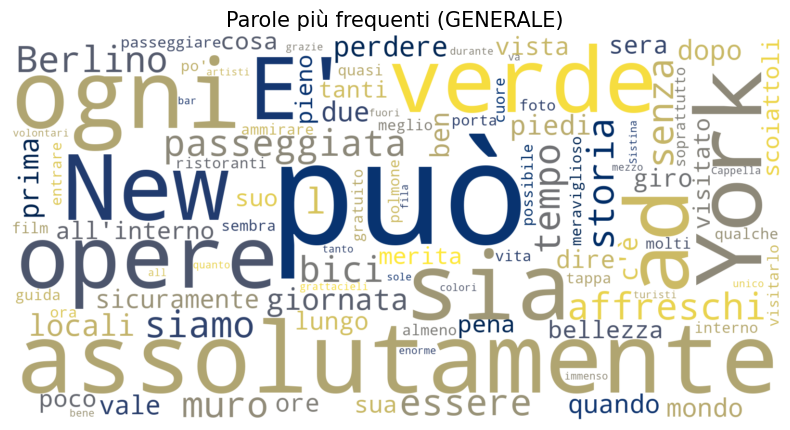

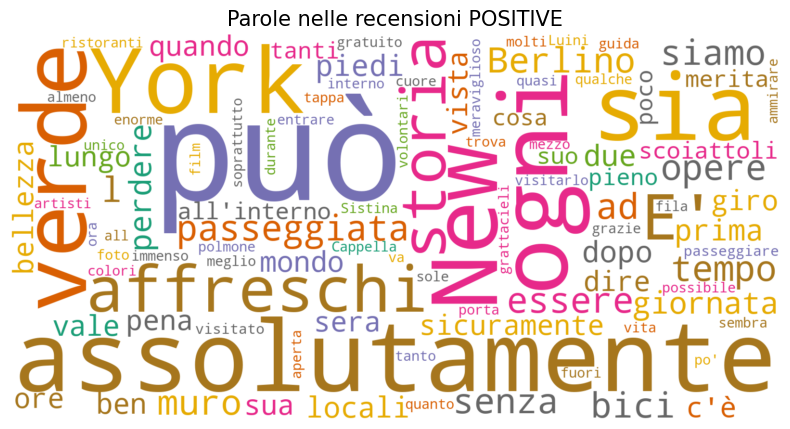

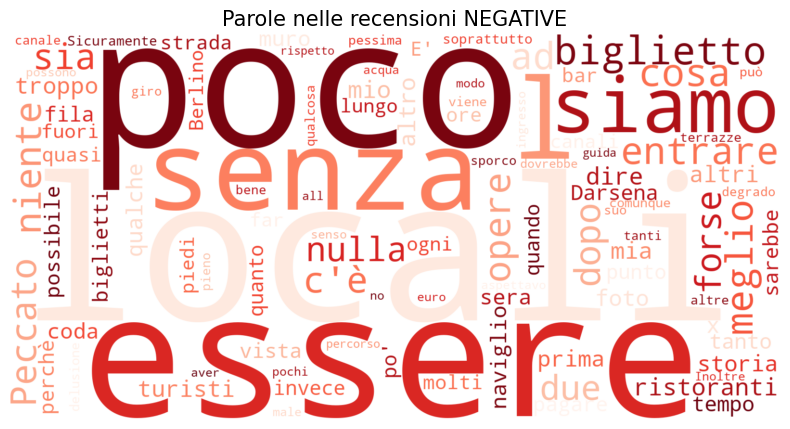

In [16]:
#ANALISI DESCRITTIVA

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# --- 1. LISTA STOPWORDS DEFINITIVA (AGGIORNATA) ---
stopwords = set([
    # Articoli e Preposizioni Semplici
    'di', 'a', 'da', 'in', 'con', 'su', 'per', 'tra', 'fra', 
    'il', 'lo', 'la', 'i', 'gli', 'le', 'un', 'uno', 'una', 
    
    # Preposizioni Articolate (Quelle che ti davano fastidio)
    'del', 'dello', 'della', 'dei', 'degli', 'delle',
    'al', 'allo', 'alla', 'ai', 'agli', 'alle',
    'dal', 'dallo', 'dalla', 'dai', 'dagli', 'dalle',
    'nel', 'nello', 'nella', 'nei', 'negli', 'nelle',
    'sul', 'sullo', 'sulla', 'sui', 'sugli', 'sulle',
    'col', 'coi', 
    
    # Congiunzioni e Connettivi
    'e', 'ed', 'o', 'od', 'ma', 'se', 'perché', 'anche', 'che', 'chi', 'cui', 
    'non', 'molto', 'più', 'meno', 'mentre', 'invece', 'infatti', 'quindi','questo','quello',
    'quegli', 'quelli',
    
    # Pronomi e Particelle
    'mi', 'ti', 'ci', 'si', 'vi', 'ne', 'li', 'lo', 'la', 'le', 'me', 'te', 'se', 'ce',
    'io', 'tu', 'lui', 'lei', 'noi', 'voi', 'loro', 'esso', 'essa', 'essi', 'esse',
    
    # Verbi Ausiliari e Comuni
    'è', 'sono', 'era', 'erano', 'stato', 'stata', 'stati', 'state', 
    'ho', 'hai', 'ha', 'abbiamo', 'avete', 'hanno', 'avevo', 'aveva',
    'fatto', 'fare', 'fa', 'fanno', 'sto', 'stai', 'sta', 'stiamo', 'stanno',
    
    # Avverbi di tempo/luogo
    'qui', 'qua', 'lì', 'là', 'dove', 'come', 'quando', 'dopo', 'prima', 
    'adesso', 'ora', 'poi', 'già', 'ancora', 'sempre', 'mai',
    'tutto', 'tutti', 'tutta', 'tutte', 'ogni', 'qualche',
    
    # Parole Dominio-Specifiche (da togliere per pulire il grafico)
    'milano', 'duomo', 'città', 'posto', 'luogo', 'visita', 
    'consiglio', 'consigliato', 'consigliare', 'vedere', 'visto',
    'esperienza', 'centro', 'piazza', 'volta', 'volte', 'giorno', 
    'anni', 'cose', 'persone', 'gente', 'parte', 'davvero', 'veramente'
])

stopwords = set([
    # Articoli, Preposizioni, Pronomi (Già visti prima)
    'di', 'a', 'da', 'in', 'con', 'su', 'per', 'tra', 'fra', 
    'il', 'lo', 'la', 'i', 'gli', 'le', 'un', 'uno', 'una', 
    'del', 'dello', 'della', 'dei', 'degli', 'delle',
    'al', 'allo', 'alla', 'ai', 'agli', 'alle',
    'dal', 'dallo', 'dalla', 'dai', 'dagli', 'dalle',
    'nel', 'nello', 'nella', 'nei', 'negli', 'nelle',
    'sul', 'sullo', 'sulla', 'sui', 'sugli', 'sulle',
    'mi', 'ti', 'ci', 'si', 'vi', 'li', 'lo', 'la', 'le', 'ne', 'ce', 'me', 'te',
    'io', 'tu', 'lui', 'lei', 'noi', 'voi', 'loro',
    'che', 'chi', 'cui', 'non', 'e', 'ed', 'o', 'ma', 'se', 'perché', 'come', 'dove',
    
    # Verbi comuni
    'è', 'sono', 'era', 'erano', 'stato', 'stata', 'stati', 'state', 
    'ho', 'hai', 'ha', 'abbiamo', 'avete', 'hanno', 'avevo',
    'fatto', 'fare', 'fa', 'fanno', 'sto', 'stai', 'sta', 'stiamo', 'stanno',
    'andare', 'andati', 'visto', 'vedere', 'fatto', 'fare', 'trovato',
    
    # Avverbi e riempitivi
    'molto', 'più', 'meno', 'tutto', 'tutti', 'tutta', 'tutte', 
    'solo', 'soltanto', 'sempre', 'mai', 'ancora', 'già', 'poi', 'qui', 'lì',
    'davvero', 'veramente', 'proprio', 'abbastanza', 'così', 'quindi', 'infatti','questo','quello',
    'quegli', 'quelli', 'quella', 'quelle','questa',
    
    # Parole Dominio (Milano) - DA RIMUOVERE PER VEDERE IL SENTIMENT
    'milano', 'duomo', 'città', 'posto', 'luogo', 'visita', 'consiglio', 'consigliato', 
    'esperienza', 'centro', 'piazza', 'volta', 'volte', 'giorno', 'anni', 'cose',
    'persone', 'gente', 'parte', 'zona', 'quartiere','central', 'park',
    
    # AGGETTIVI GENERICI (Questi rendono le nuvole uguali, togliamoli!)
    'bello', 'bella', 'belli', 'belle', 'bellissimo', 'bellissima', 
    'grande', 'grandi', 'piccolo', 'piccola', 
    'buono', 'buona', 'ottimo', 'ottima', 'interessante','museo','anche','parco','visitare','chiesa','navigli'
])

# --- 2. GRAFICO DISTRIBUZIONE SENTIMENT ---
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, order=['positive', 'neutral', 'negative'], palette='viridis')
plt.title('Distribuzione dei Sentimenti (Dataset Originale)')
plt.savefig('distribuzione_sentiment.png')
plt.show()

# --- 3. GENERAZIONE WORDCLOUD ---
def genera_wordcloud(testo_series, titolo, file_name, colormap_name):
    # Unisce tutti i commenti in un unico testo gigante
    testo = " ".join(review for review in testo_series.astype(str))
    
    # Crea la WordCloud
    wc = WordCloud(
        width=1600, height=800,           
        background_color='white',         
        stopwords=stopwords,
        min_font_size=10,
        max_words=100,                    
        colormap=colormap_name,
        collocations=False  # <--- FONDAMENTALE: Evita che scriva "del duomo" unito
    ).generate(testo)

    # Disegna
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off') 
    plt.title(titolo, fontsize=15)
    plt.savefig(file_name) 
    plt.show()

print("Generazione WordCloud PULITE in corso...")

# A) WordCloud GENERALE
genera_wordcloud(df['comment'], 'Parole più frequenti (GENERALE)', 'wc_generale.png','cividis')

# B) WordCloud POSITIVE (Filtra solo positive)
genera_wordcloud(df[df['sentiment']=='positive']['comment'], 'Parole nelle recensioni POSITIVE', 'wc_positive.png','Dark2')

# C) WordCloud NEGATIVE (Filtra solo negative)
genera_wordcloud(df[df['sentiment']=='negative']['comment'], 'Parole nelle recensioni NEGATIVE', 'wc_negative.png','Reds')

Da qui in poi sono tutte celle dedicate alla Text Classification con FastText, sono 3 prove. Nell'ultima faccio una classificazione binaria tra Positive e Negative dato che i neutral facevano confondere troppo il modello diminuendo di molto la precision e la recall.

In [1]:
#FastText addestrato sul dataset bilanciato
import pandas as pd
import fasttext
from sklearn.model_selection import train_test_split
import os

# 1. CARICAMENTO DATASET BILANCIATO
# Usiamo quello creato nello step precedente
filename = 'LLM_DF_Balanced.csv'

if not os.path.exists(filename):
    print(f"ERRORE: Non trovo il file {filename}. Assicurati di aver eseguito il codice precedente!")
else:
    df = pd.read_csv(filename)
    print(f"Dataset caricato: {len(df)} righe.")

    # 2. PREPARAZIONE FORMATO FASTTEXT
    # FastText vuole questo formato esatto: "__label__positive Il testo della recensione..."
    # Dobbiamo anche rimuovere i caratteri di 'a capo' (\n) perché FastText usa una riga per documento.
    
    def clean_for_fasttext(text):
        return str(text).replace('\n', ' ').replace('\r', ' ')

    df['clean_comment'] = df['comment'].apply(clean_for_fasttext)
    
    # Creiamo la colonna finale formattata
    df['fasttext_line'] = '__label__' + df['sentiment'] + ' ' + df['clean_comment']

    # 3. DIVISIONE TRAIN (80%) E TEST (20%)
    train, test = train_test_split(df, test_size=0.2, random_state=42)

    # Salviamo i file .txt su disco (FastText legge solo da file)
    train['fasttext_line'].to_csv('train.txt', index=False, header=False)
    test['fasttext_line'].to_csv('test.txt', index=False, header=False)
    print("File 'train.txt' e 'test.txt' creati con successo.")

    # 4. ADDESTRAMENTO (Training)
    # Usiamo i parametri suggeriti nella tesina di esempio (Pagina 19)
    print("Inizio addestramento modello...")
    model = fasttext.train_supervised(
        input="train.txt", 
        epoch=25,       # Numero di passaggi sui dati
        lr=0.5,         # Learning rate (velocità di apprendimento)
        wordNgrams=3,   # Considera gruppi di 3 parole (es. "non mi piace")
        verbose=2
    )
    print("Modello addestrato!")

    # 5. VALUTAZIONE (Testing)
    # model.test restituisce una tupla: (numero_campioni, precision, recall)
    result = model.test("test.txt")
    
    n_samples = result[0]
    precision = result[1]
    recall = result[2]

    print("\n--- RISULTATI CLASSIFICAZIONE (FastText) ---")
    print(f"Campioni testati: {n_samples}")
    print(f"Precision: {precision:.4f} (Tesina esempio: ~0.69)")
    print(f"Recall:    {recall:.4f}    (Tesina esempio: ~0.69)")

    # 6. PROVA PRATICA MANUALE
    print("\n--- TEST LIVE ---")
    # Proviamo frasi in italiano per vedere se capisce meglio di TextBlob
    frasi_test = [
        "Il duomo è stupendo e milano è bellissima",     # Dovrebbe essere positive
        "Purtroppo c'era troppa fila e pioveva",         # Dovrebbe essere negative/neutral
        "Non mi è piaciuto per niente, sporco",          # Dovrebbe essere negative
        "Esperienza normale, niente di speciale"         # Dovrebbe essere neutral
    ]

    for frase in frasi_test:
        predizione = model.predict(frase) # Restituisce ((label,), (prob,))
        label = predizione[0][0].replace('__label__', '')
        print(f"Frase: '{frase}' -> {label.upper()}")

Dataset caricato: 1044 righe.
File 'train.txt' e 'test.txt' creati con successo.
Inizio addestramento modello...


Read 0M words
Number of words:  10629
Number of labels: 3


Modello addestrato!

--- RISULTATI CLASSIFICAZIONE (FastText) ---
Campioni testati: 65
Precision: 0.3846 (Tesina esempio: ~0.69)
Recall:    0.3846    (Tesina esempio: ~0.69)

--- TEST LIVE ---
Frase: 'Il duomo è stupendo e milano è bellissima' -> POSITIVE
Frase: 'Purtroppo c'era troppa fila e pioveva' -> POSITIVE
Frase: 'Non mi è piaciuto per niente, sporco' -> NEGATIVE
Frase: 'Esperienza normale, niente di speciale' -> NEUTRAL


Progress: 100.0% words/sec/thread: 1603476 lr:  0.000000 avg.loss:  0.969494 ETA:   0h 0m 0s


: 

In [2]:
import pandas as pd
import fasttext
from sklearn.model_selection import train_test_split
import os
import re # Libreria per le espressioni regolari (pulizia testo)

# 1. CARICAMENTO
filename = 'LLM_DF_Balanced.csv'
if os.path.exists(filename):
    df = pd.read_csv(filename)
    
    # 2. PULIZIA MIGLIORATA (Lowercase + Rimozione Punteggiatura)
    def clean_text_better(text):
        text = str(text).lower()                 # Tutto minuscolo
        text = re.sub(r'[^\w\s]', '', text)      # Rimuove punteggiatura (!, ., ?, ecc.)
        text = text.replace('\n', ' ')           # Rimuove a capo
        return text

    df['clean_comment'] = df['comment'].apply(clean_text_better)
    
    # Formato FastText
    df['fasttext_line'] = '__label__' + df['sentiment'] + ' ' + df['clean_comment']

    # 3. DIVISIONE TRAIN/TEST
    train, test = train_test_split(df, test_size=0.2, random_state=42)

    train['fasttext_line'].to_csv('train.txt', index=False, header=False)
    test['fasttext_line'].to_csv('test.txt', index=False, header=False)

    # 4. ADDESTRAMENTO POTENZIATO
    # Aumentiamo le epoche a 100 perché abbiamo pochi dati
    print("Inizio addestramento modello (100 epoche)...")
    model = fasttext.train_supervised(
        input="train.txt", 
        epoch=100,      # AUMENTATO DA 25 A 100
        lr=0.5,         # Learning rate aggressivo
        wordNgrams=2,   # Proviamo a 2 (bigrammi) invece di 3, spesso meglio con pochi dati
        verbose=1
    )
    print("Modello addestrato!")

    # 5. VALUTAZIONE
    result = model.test("test.txt")
    print("\n--- RISULTATI CLASSIFICAZIONE (FastText Migliorato) ---")
    print(f"Campioni: {result[0]}")
    print(f"Precision: {result[1]:.4f}")
    print(f"Recall:    {result[2]:.4f}")

    # 6. TEST LIVE (Ricorda di pulire anche le frasi di test!)
    print("\n--- TEST LIVE ---")
    frasi_test = [
        "Il duomo è stupendo e milano è bellissima",
        "Purtroppo c'era troppa fila e pioveva", 
        "Non mi è piaciuto per niente, sporco", 
        "Esperienza normale, niente di speciale"
    ]

    for frase in frasi_test:
        # Importante: puliamo la frase nello stesso modo del training
        frase_pulita = clean_text_better(frase) 
        predizione = model.predict(frase_pulita)
        label = predizione[0][0].replace('__label__', '')
        score = predizione[1][0]
        print(f"Frase: '{frase}' -> {label.upper()} ({score:.2f})")
else:
    print("File non trovato!")

Inizio addestramento modello (100 epoche)...


Read 0M words
Number of words:  7431
Number of labels: 3


Modello addestrato!

--- RISULTATI CLASSIFICAZIONE (FastText Migliorato) ---
Campioni: 209
Precision: 0.5598
Recall:    0.5598

--- TEST LIVE ---
Frase: 'Il duomo è stupendo e milano è bellissima' -> POSITIVE (1.00)
Frase: 'Purtroppo c'era troppa fila e pioveva' -> NEUTRAL (1.00)
Frase: 'Non mi è piaciuto per niente, sporco' -> NEGATIVE (0.54)
Frase: 'Esperienza normale, niente di speciale' -> NEGATIVE (0.99)


Progress: 100.0% words/sec/thread: 2085005 lr:  0.000000 avg.loss:  0.090746 ETA:   0h 0m 0s


In [3]:
#Codice con classificazione binaria (Positivi vs Negativi)
import pandas as pd
import fasttext
from sklearn.model_selection import train_test_split
import os
import re

# 1. CARICAMENTO DATI
filename = 'LLM_DF.csv'
df = pd.read_csv(filename)

# Mappatura Sentiment
def map_sentiment(star):
    if star >= 4: return 'positive'
    elif star <= 2: return 'negative'
    else: return 'neutral'

df['sentiment'] = df['stars'].apply(map_sentiment)

# --- STRATEGIA BINARIA: RIMUOVIAMO I NEUTRAL ---
# Questo semplifica il lavoro al modello e alza la precisione
df_binary = df[df['sentiment'] != 'neutral'].copy()

# Bilanciamento (Ora abbiamo solo 2 classi)
df_pos = df_binary[df_binary['sentiment'] == 'positive']
df_neg = df_binary[df_binary['sentiment'] == 'negative']

min_count = min(len(df_pos), len(df_neg))
print(f"Addestramento su {min_count} recensioni Positive e {min_count} Negative")

# Creiamo il dataset bilanciato
df_pos_bal = df_pos.sample(n=min_count, random_state=42)
df_neg_bal = df_neg.sample(n=min_count, random_state=42)
df_final = pd.concat([df_pos_bal, df_neg_bal])
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. PULIZIA TESTO APPROFONDITA
def clean_text(text):
    text = str(text).lower()                 # Tutto minuscolo
    text = re.sub(r'[^\w\s]', '', text)      # Via la punteggiatura
    text = text.replace('\n', ' ')           # Via gli a capo
    return text

df_final['clean_comment'] = df_final['comment'].apply(clean_text)
df_final['fasttext_line'] = '__label__' + df_final['sentiment'] + ' ' + df_final['clean_comment']

# 3. CREAZIONE FILE TRAIN/TEST
train, test = train_test_split(df_final, test_size=0.2, random_state=42)

train['fasttext_line'].to_csv('train_bin.txt', index=False, header=False)
test['fasttext_line'].to_csv('test_bin.txt', index=False, header=False)

# 4. ADDESTRAMENTO
print("Inizio addestramento...")
model = fasttext.train_supervised(
    input="train_bin.txt", 
    epoch=100,       # Tante epoche per imparare bene dai pochi dati
    lr=1.0,          # Learning rate aggressivo
    wordNgrams=2,    # Bigrammi (coppie di parole)
    verbose=1
)

# 5. VALUTAZIONE
result = model.test("test_bin.txt")
print("\n--- RISULTATI FINALI (Positivo vs Negativo) ---")
print(f"Campioni testati: {result[0]}")
print(f"Precision: {result[1]:.4f}") 
print(f"Recall:    {result[2]:.4f}")

# 6. TEST LIVE
print("\n--- TEST REALE ---")
frasi = [
    "Il duomo è stupendo, esperienza magnifica",
    "Che schifo, tutto sporco e personale scortese",
    "Non ci tornerei mai più, pessimo",
    "Bellissimo posto, molto consigliato"
]

for f in frasi:
    # Puliamo la frase come abbiamo fatto per il training
    pred = model.predict(clean_text(f))
    lbl = pred[0][0].replace('__label__', '')
    print(f"'{f}' -> {lbl.upper()}")

Addestramento su 348 recensioni Positive e 348 Negative
Inizio addestramento...


Read 0M words
Number of words:  6053
Number of labels: 2



--- RISULTATI FINALI (Positivo vs Negativo) ---
Campioni testati: 140
Precision: 0.7929
Recall:    0.7929

--- TEST REALE ---
'Il duomo è stupendo, esperienza magnifica' -> POSITIVE
'Che schifo, tutto sporco e personale scortese' -> POSITIVE
'Non ci tornerei mai più, pessimo' -> NEGATIVE
'Bellissimo posto, molto consigliato' -> POSITIVE


Progress: 100.0% words/sec/thread: 2177398 lr:  0.000000 avg.loss:  0.023333 ETA:   0h 0m 0s
